**-----------------------------------------------------IMDB sentiment classification dataset----------------------------------------------------**

In [ ]:
from keras.datasets import imdb

**Loads the IMDB movie reviews dataset from Keras.**

This dataset is preprocessed, where:

Each review is already converted to a sequence of integers.

Each integer represents a word's index in the dataset's vocabulary.

num_words=vocabulary_size ensures only the top 10,000 words are used.

The function returns:

X_train: List of training review sequences.

y_train: Labels (0 for negative, 1 for positive).

X_test: List of test review sequences.

y_test: Corresponding test labels.

In [ ]:
vocabulary_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words = vocabulary_size)
print('Loaded dataset with {} training samples, {} test samples'.format(len(X_train), len(X_test)))

Loaded dataset with 25000 training samples, 25000 test samples


In [ ]:
print('---review---')
print(X_train[6])
print('---label---')
print(y_train[6])

---review---
[1, 6740, 365, 1234, 5, 1156, 354, 11, 14, 5327, 6638, 7, 1016, 2, 5940, 356, 44, 4, 1349, 500, 746, 5, 200, 4, 4132, 11, 2, 9363, 1117, 1831, 7485, 5, 4831, 26, 6, 2, 4183, 17, 369, 37, 215, 1345, 143, 2, 5, 1838, 8, 1974, 15, 36, 119, 257, 85, 52, 486, 9, 6, 2, 8564, 63, 271, 6, 196, 96, 949, 4121, 4, 2, 7, 4, 2212, 2436, 819, 63, 47, 77, 7175, 180, 6, 227, 11, 94, 2494, 2, 13, 423, 4, 168, 7, 4, 22, 5, 89, 665, 71, 270, 56, 5, 13, 197, 12, 161, 5390, 99, 76, 23, 2, 7, 419, 665, 40, 91, 85, 108, 7, 4, 2084, 5, 4773, 81, 55, 52, 1901]
---label---
1


**imdb.get_word_index()** returns a dictionary where:

Keys are words (e.g., "the", "great", "awful")

Values are unique integer indices representing those words.

**id2word = {i: word for word, i in word2id.items()}** This is a reverse mapping of the dictionary. Now:

Keys are the IDs (integers).

Values are the words.

In [ ]:
word2id = imdb.get_word_index()
id2word = {i + 3: word for word, i in word2id.items()} # this help us convert tokens back to human readable texts
id2word[0] = "<PAD>"
id2word[1] = "<START>"
id2word[2] = "<UNK>"
id2word[3] = "<UNUSED>"
print('---review with words---')
print([id2word.get(i, '?') for i in X_train[6]])
print('---label---')
print(y_train[6])

---review with words---
['the', 'boiled', 'full', 'involving', 'to', 'impressive', 'boring', 'this', 'as', 'murdering', 'naschy', 'br', 'villain', 'and', 'suggestion', 'need', 'has', 'of', 'costumes', 'b', 'message', 'to', 'may', 'of', 'props', 'this', 'and', 'concentrates', 'concept', 'issue', 'skeptical', 'to', "god's", 'he', 'is', 'and', 'unfolds', 'movie', 'women', 'like', "isn't", 'surely', "i'm", 'and', 'to', 'toward', 'in', "here's", 'for', 'from', 'did', 'having', 'because', 'very', 'quality', 'it', 'is', 'and', 'starship', 'really', 'book', 'is', 'both', 'too', 'worked', 'carl', 'of', 'and', 'br', 'of', 'reviewer', 'closer', 'figure', 'really', 'there', 'will', 'originals', 'things', 'is', 'far', 'this', 'make', 'mistakes', 'and', 'was', "couldn't", 'of', 'few', 'br', 'of', 'you', 'to', "don't", 'female', 'than', 'place', 'she', 'to', 'was', 'between', 'that', 'nothing', 'dose', 'movies', 'get', 'are', 'and', 'br', 'yes', 'female', 'just', 'its', 'because', 'many', 'br', 'of',

In [ ]:
print('Maximum review length: {}'.format(
len(max((X_train + X_test), key=len))))

Maximum review length: 2697


In [ ]:
print('Minimum review length: {}'.format(
len(min((X_test + X_test), key=len))))

Minimum review length: 14


**X_train and X_test** are both lists of integer-encoded movie reviews.

Each review is a sequence of integers, where each integer represents a word (based on a dictionary built from the dataset).

**np.concatenate(...)** combines X_train and X_test into one long array called allreviews.

**axis=0** means we are stacking them vertically (one after another).

After this line, allreviews contains all the reviews (training + test) in a single array.

**[len(x) for x in allreviews]** This is a list comprehension.

For each review x in allreviews, it calculates len(x) — i.e., the number of words (tokens) in that review.

np.mean(result) calculates the average number of words per review.

In [ ]:
allreviews = np.concatenate((X_train, X_test), axis=0)
result = [len(x) for x in allreviews]
print("Mean review length: {}".format(np.mean(result)))

Mean review length: 234.75892


**pad_sequences** makes sure all input reviews are of equal length.

If a review is shorter than max_words, it pads it with 0s at the beginning (default).

If a review is longer, it truncates it from the beginning to fit the length.

In [ ]:
from keras.preprocessing import sequence

max_words = 500
X_train = sequence.pad_sequences(X_train, maxlen=max_words)
X_test = sequence.pad_sequences(X_test, maxlen=max_words)

In [ ]:
X_train[10]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    1,  785,  189,  438,   47,
        110,  142,    7,    6, 7475,  120,    4,  236,  378,    7,  153,
         19,   87,  108,  141,   17, 1004,    5,    2,  883,    2,   23,
          8,    4,  136,    2,    2,    4, 7475,   43, 1076,   21, 1407,
        419,    5, 5202,  120,   91,  682,  189, 2818,    5,    9, 1348,
         31,    7,    4,  118,  785,  189,  108,  126,   93,    2,   16,
        540,  324,   23,    6,  364,  352,   21,   14,    9,   93,   56,
         18,   11,  230,   53,  771,   74,   31,   34,    4, 2834,    7,
          4,   22,    5,   14,   11,  471,    9,    2,   34,    4,  321,
        487,    5,  116,   15, 6584,    4,   22,   

Shape of training and testing data

In [ ]:
print("Shape Training Review Data: " + str(X_train.shape))
print("Shape Training Class Data: " + str(y_train.shape))
print("Shape Test Review Data: " + str(X_test.shape))
print("Shape Test Class Data: " + str(y_test.shape))

Shape Training Review Data: (25000, 500)
Shape Training Class Data: (25000,)
Shape Test Review Data: (25000, 500)
Shape Test Class Data: (25000,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Embedding, SimpleRNN, Dense, Dropout,LSTM,Bidirectional
from tensorflow.keras.callbacks import EarlyStopping


Model Architecture

In [ ]:
model = Sequential()

model.add(Input(shape=(max_words,)))

model.add(Embedding(input_dim=vocabulary_size,output_dim=32))

model.add(Dropout(0.25))

model.add(Bidirectional(SimpleRNN(32)))

model.add(Dropout(0.25))

model.add(Dense(1,activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,225 (1.24 MB)

 Trainable params: 324,225 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

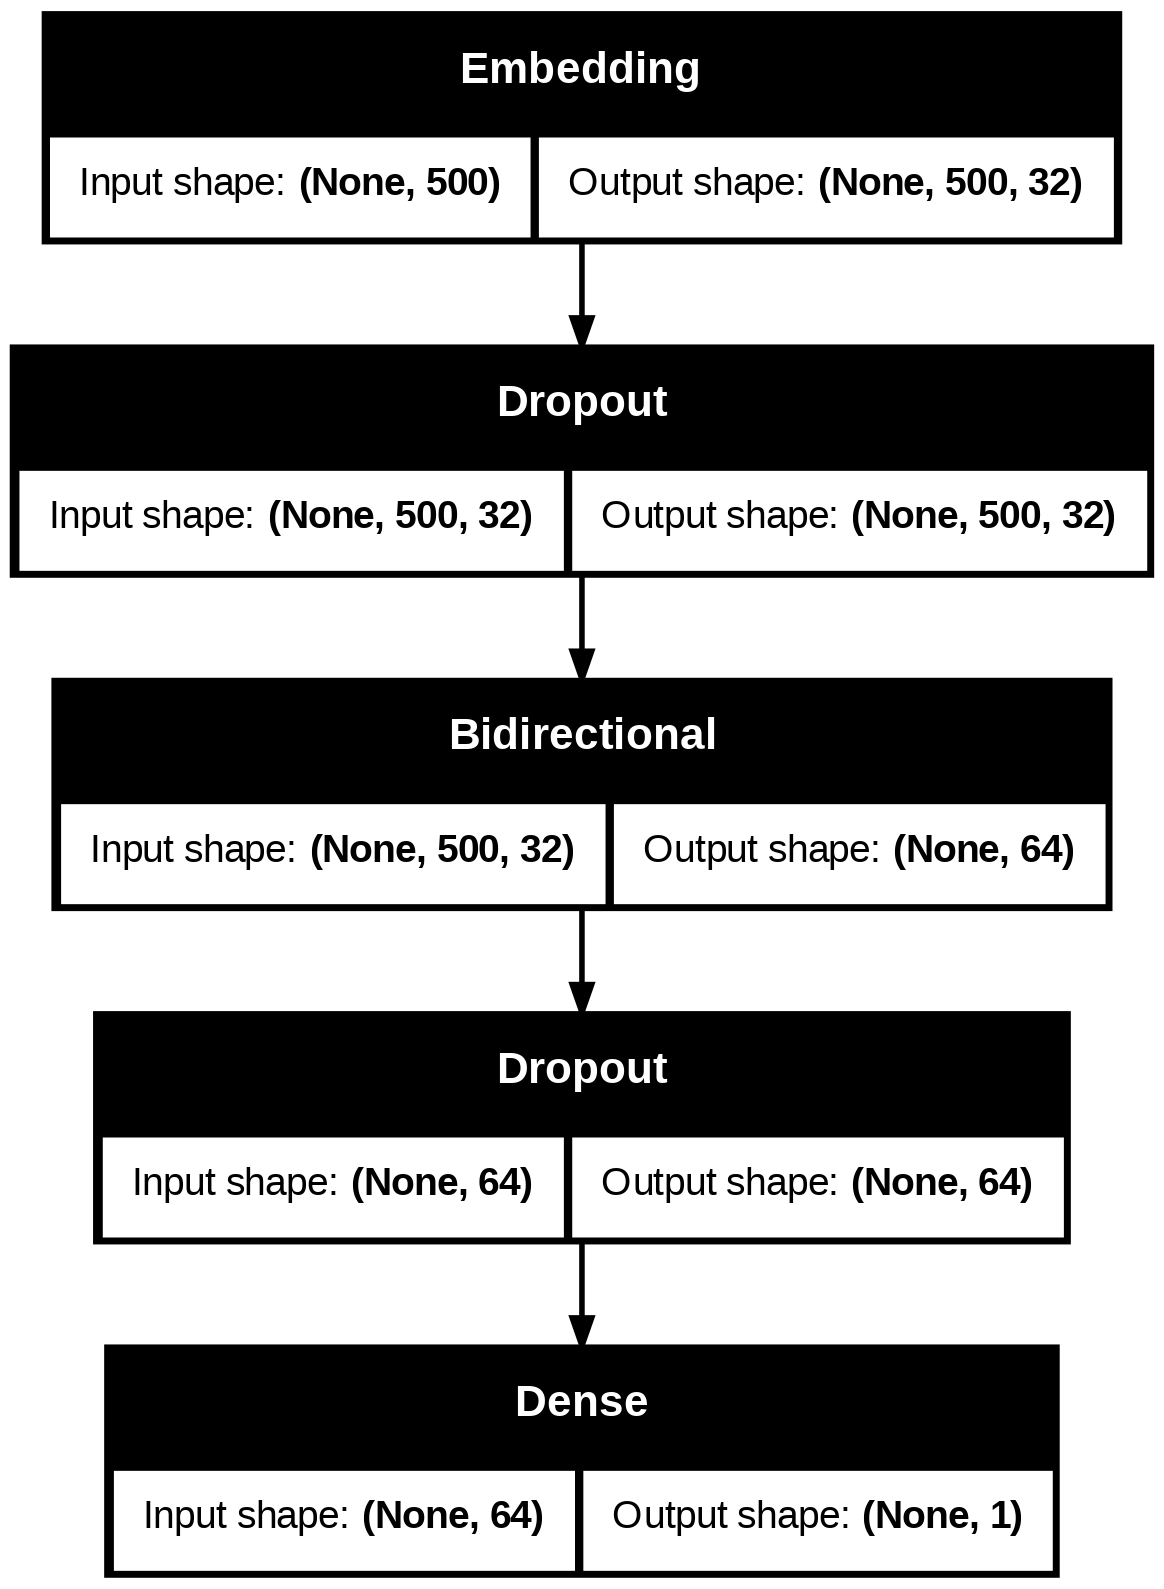

In [ ]:
tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=False)

Actual training

In [ ]:

history = model.fit(

    # Training data : features (review) and classes (positive or negative)
    X_train, y_train,

    # Number of samples to work through before updating the
    # internal model parameters via back propagation. The
    # higher the batch, the more memory you need.
    batch_size=256,

    # An epoch is an iteration over the entire training data.
    epochs=10,

    # The model will set apart this fraction of the training
    # data, and will not train on it, and will evaluate the loss
    # and any model metrics on this data at the end of
    # each epoch.
    validation_split=0.2,

    verbose=1
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.5135 - loss: 0.6967 - val_accuracy: 0.5888 - val_loss: 0.6778
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.6451 - loss: 0.6467 - val_accuracy: 0.7476 - val_loss: 0.5518
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.8257 - loss: 0.4459 - val_accuracy: 0.8234 - val_loss: 0.4199
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.8700 - loss: 0.3348 - val_accuracy: 0.8462 - val_loss: 0.3717
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.9102 - loss: 0.2488 - val_accuracy: 0.8478 - val_loss: 0.3805
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.9234 - loss: 0.2088 - val_accuracy: 0.8412 - val_loss: 0.3880
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.9439 - loss: 0.1628 - val_accuracy: 0.8414 - val_loss: 0.3969
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.9650 - loss: 0.1155 - val_accuracy: 0.83

Predicting on Test data and printing classification report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix

# Get probabilities
# The model outputs a probability score between 0 and 1 for each sample in X_test.
y_probs = model.predict(X_test) # These are not labels, just the model's confidence that a sample belongs to the positive class.


# Convert probabilities to class labels (0 or 1)
predicted_classes = (y_probs > 0.5).astype("int32").flatten() """If the probability is greater than 0.5, predict class 1 (Positive).

Otherwise, predict class 0 (Negative).

.astype("int32") converts boolean values to integers.

.flatten() turns the 2D array (like shape (n, 1)) into a 1D array (n,)."""

# Classification report
class_names = ["Negative", "Positive"]
print(classification_report(y_test, predicted_classes, target_names=class_names))


782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.84     12500
    Positive       0.85      0.84      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

In [ ]:
print("AUC-SCORE -->",roc_auc_score(y_test,predicted_classes)*100)

AUC-SCORE --> 84.39599999999999


In [ ]:
cm = confusion_matrix(y_test,predicted_classes)

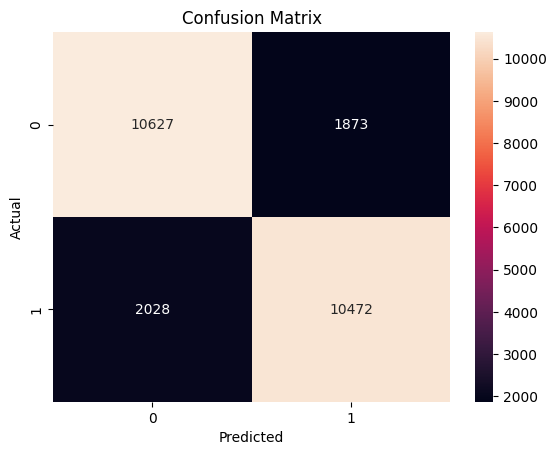

In [ ]:
plt.title("Confusion Matrix")
sns.heatmap(cm ,annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


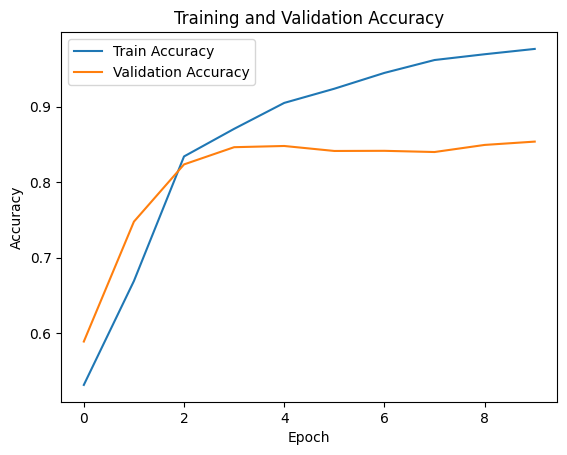

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Prediction on Test data using the trained model.

In [ ]:
# Helper: decode review back to words
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review if i >= 3])

# Make predictions
num_samples_to_display = 10
sample_indices = np.random.choice(len(X_test), num_samples_to_display, replace=False)

# Get predicted probabilities
y_probs = model.predict(X_test[sample_indices])

# Convert to class labels
predicted_labels = (y_probs > 0.5).astype("int32").flatten()
actual_labels = y_test[sample_indices]

# Display each review
for i in range(num_samples_to_display):
    print(f"\n--- Review {i+1} ---")
    print("Review (decoded):")
    print(decode_review(X_test[sample_indices[i]]))  # Decoded review
    print(f"\nPredicted Label: {'Positive' if predicted_labels[i] == 1 else 'Negative'}")
    print(f"Actual Label: {'Positive' if actual_labels[i] == 1 else 'Negative'}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step

--- Review 1 ---
Review (decoded):
this 1955 showcase version of the musical peter pan with mary martin has the benefit of most of the original broadway cast including kathleen nolan as wendy who was more natural an actress than the girl they hired for the 1960 color play it's a shame that most people won't sit through anything black and white anymore because in many respects this earlier production which doesn't even show up in the imdb when you put peter pan into the search engine is superior to the color version most people have watched i the original on disc and then did work on it to make it look and sound better now when i put the 1960 color version on it looks in comparison i suspect mary martin herself no doubt preferred this original 1955 b w showcase version br br as an added plus the disc i got also showed the original commercials and opening how far away the 1950's seem now such an innocent time compared to today i miss it

Predicted 

In [ ]:
custom_sentences = [
    "The movie was absolutely wonderful and touching",        # Positive
    "I hated every second of this boring film",               # Negative
    "Fantastic acting and great plot",                        # Positive
    "It was the worst movie I have ever seen",                # Negative
    "The film had some good moments but was mostly dull",     # Negative
    "A brilliant masterpiece with stunning visuals",          # Positive
    "Mediocre storyline and forgettable characters",          # Negative
    "An excellent and emotional experience",                  # Positive
    "Terrible acting and poor direction",                     # Negative
    "Loved the soundtrack and the performances",              # Positive
]

# True labels (0 = Negative, 1 = Positive)
custom_labels = np.array([1, 0, 1, 0, 0, 1, 0, 1, 0, 1])


In [ ]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

# Load word index
word_index = imdb.get_word_index()
word_index = {k: (v + 3) for k, v in word_index.items()}  # Shift index by 3
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3

# Convert sentences to sequences
def encode_sentence(sentence):
    return [word_index.get(word, 2) for word in text_to_word_sequence(sentence)]

encoded_custom_sentences = [encode_sentence(sent) for sent in custom_sentences]

# Pad sequences to match model input length
max_words = 500  # same as used during training
padded_custom_sentences = pad_sequences(encoded_custom_sentences, maxlen=max_words)


In [ ]:
# Predict probabilities
custom_probs = model.predict(padded_custom_sentences)

# Convert to class labels
custom_preds = (custom_probs > 0.5).astype("int32").flatten()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [ ]:
for i, sentence in enumerate(custom_sentences):
    print(f"\nReview {i+1}: {sentence}")
    print(f"Predicted Sentiment: {'Positive' if custom_preds[i] == 1 else 'Negative'}")
    print(f"Actual Sentiment: {'Positive' if custom_labels[i] == 1 else 'Negative'}")



Review 1: The movie was absolutely wonderful and touching
Predicted Sentiment: Negative
Actual Sentiment: Positive

Review 2: I hated every second of this boring film
Predicted Sentiment: Negative
Actual Sentiment: Negative

Review 3: Fantastic acting and great plot
Predicted Sentiment: Negative
Actual Sentiment: Positive

Review 4: It was the worst movie I have ever seen
Predicted Sentiment: Negative
Actual Sentiment: Negative

Review 5: The film had some good moments but was mostly dull
Predicted Sentiment: Negative
Actual Sentiment: Negative

Review 6: A brilliant masterpiece with stunning visuals
Predicted Sentiment: Negative
Actual Sentiment: Positive

Review 7: Mediocre storyline and forgettable characters
Predicted Sentiment: Negative
Actual Sentiment: Negative

Review 8: An excellent and emotional experience
Predicted Sentiment: Negative
Actual Sentiment: Positive

Review 9: Terrible acting and poor direction
Predicted Sentiment: Negative
Actual Sentiment: Negative

Review 10: